# Offline ML Showcase: Flow-Based DoS/DDoS Attack Classification

This notebook is a **resume artifact, not a runtime dependency** of the live
CyberPulse system. It trains a classifier on a public, labeled, flow-based
network traffic dataset to answer a different (and complementary) question
than the live system does: *"if we had packet/flow-level access to network
traffic, how well could a classic ML pipeline distinguish DoS/DDoS attack
traffic from benign traffic and from other intrusion types?"*

See the final section for how this connects back to the live system's
actual design (Technical Architecture doc, section 5b).

## Dataset & substitution note

The original plan (per `05_FEATURE_TICKETS.md` Phase 6) was to use
**CICDDoS2019** (Canadian Institute for Cybersecurity). In practice, that
dataset turned out to be access-gated: the official UNB source requires
submitting a personal registration form (name/email/organization) to their
server, and the common Kaggle mirrors require a Kaggle account/API key.
Neither is a plain anonymous download, and this project's constraints
(reproducible, `$0`, buildable by an AI coding agent without a human in the
loop for credential-gated resources) ruled both out.

Instead, this notebook uses **NSL-KDD**, the standard, widely-used successor
to the KDD Cup 1999 dataset — a labeled, flow/connection-level intrusion
detection benchmark that is **genuinely, anonymously downloadable** (verified
directly against a public raw-file mirror, no registration or account
required) and includes a substantial DoS category (`neptune`/SYN-flood,
`smurf`, `teardrop`, `land`, `back`, `pod`, and others) alongside probe,
R2L, and U2R attack categories.

**Citation:**
> M. Tavallaee, E. Bagheri, W. Lu, and A. A. Ghorbani, "A Detailed Analysis
> of the KDD CUP 99 Data Set," *Submitted to Second IEEE Symposium on
> Computational Intelligence for Security and Defense Applications (CISDA)*,
> 2009.

Distributed here via a public GitHub mirror
(`jmnwong/NSL-KDD-Dataset`) of the dataset originally hosted by the
University of New Brunswick's Canadian Institute for Cybersecurity, used
here for non-commercial academic/portfolio purposes with attribution.

## 1. Setup & data download

Downloads the train/test files if not already present in `data/` (gitignored — re-fetched on a fresh clone rather than committed).

In [1]:
import urllib.request
from pathlib import Path

DATA_DIR = Path("data")
DATA_DIR.mkdir(exist_ok=True)

BASE_URL = "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/"
FILES = {
    "KDDTrain+_20Percent.txt": "KDDTrain%2B_20Percent.txt",
    "KDDTest+.txt": "KDDTest%2B.txt",
}

for local_name, remote_name in FILES.items():
    local_path = DATA_DIR / local_name
    if local_path.exists():
        print(f"already have {local_name}")
        continue
    url = BASE_URL + remote_name
    print(f"downloading {local_name} from {url}")
    urllib.request.urlretrieve(url, local_path)
    print(f"  -> {local_path.stat().st_size:,} bytes")


downloading KDDTrain+_20Percent.txt from https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B_20Percent.txt


  -> 3,822,033 bytes
downloading KDDTest+.txt from https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTest%2B.txt


  -> 3,441,513 bytes


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

sns.set_theme(style="darkgrid")
RANDOM_STATE = 42


## 2. Load data & assign column names

NSL-KDD ships without a header row. The 41 feature names plus `label` and
`difficulty` are the standard, publicly documented schema for this dataset.

In [3]:
COLUMN_NAMES = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty",
]

train_df = pd.read_csv(DATA_DIR / "KDDTrain+_20Percent.txt", names=COLUMN_NAMES)
test_df = pd.read_csv(DATA_DIR / "KDDTest+.txt", names=COLUMN_NAMES)

print(f"train: {train_df.shape}, test: {test_df.shape}")
train_df.head()


train: (25192, 43), test: (22544, 43)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,label,difficulty
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


## 3. Attack taxonomy

NSL-KDD's `label` column has ~40 fine-grained attack names (e.g. `neptune`,
`smurf`, `satan`, `guess_passwd`, `buffer_overflow`...). We map these to the
standard 5-class taxonomy used throughout the NSL-KDD literature: `normal`,
`dos`, `probe`, `r2l` (remote-to-local), `u2r` (user-to-root). This mapping
is the conventional one used in NSL-KDD research (Tavallaee et al. and
widely-replicated follow-on work), not something invented for this
notebook.

In [4]:
ATTACK_CATEGORY = {
    "normal": "normal",
    # DoS
    "back": "dos", "land": "dos", "neptune": "dos", "pod": "dos", "smurf": "dos",
    "teardrop": "dos", "apache2": "dos", "udpstorm": "dos", "processtable": "dos",
    "worm": "dos", "mailbomb": "dos",
    # Probe
    "satan": "probe", "ipsweep": "probe", "nmap": "probe", "portsweep": "probe",
    "mscan": "probe", "saint": "probe",
    # R2L
    "guess_passwd": "r2l", "ftp_write": "r2l", "imap": "r2l", "phf": "r2l",
    "multihop": "r2l", "warezmaster": "r2l", "warezclient": "r2l", "spy": "r2l",
    "xlock": "r2l", "xsnoop": "r2l", "snmpguess": "r2l", "snmpgetattack": "r2l",
    "httptunnel": "r2l", "sendmail": "r2l", "named": "r2l",
    # U2R
    "buffer_overflow": "u2r", "loadmodule": "u2r", "rootkit": "u2r",
    "perl": "u2r", "sqlattack": "u2r", "xterm": "u2r", "ps": "u2r",
}

def map_category(label: str) -> str:
    return ATTACK_CATEGORY.get(label, "unknown")

for df in (train_df, test_df):
    df["attack_category"] = df["label"].apply(map_category)

unknown = sorted(set(train_df.loc[train_df["attack_category"] == "unknown", "label"]) |
                  set(test_df.loc[test_df["attack_category"] == "unknown", "label"]))
print("unmapped labels (should be empty):", unknown)

train_df["attack_category"].value_counts()


unmapped labels (should be empty): []


attack_category
normal    13449
dos        9234
probe      2289
r2l         209
u2r          11
Name: count, dtype: int64

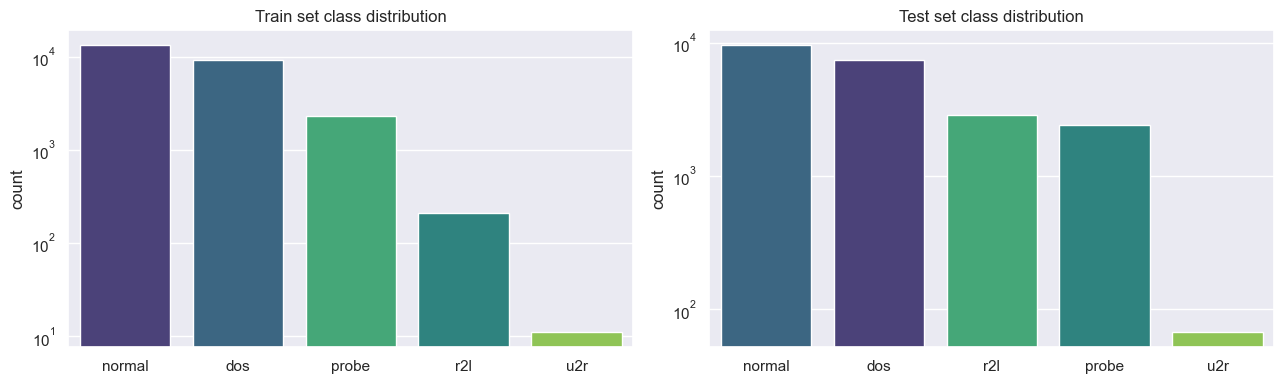

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, df, title in zip(axes, (train_df, test_df), ("Train", "Test")):
    order = df["attack_category"].value_counts().index
    sns.countplot(data=df, x="attack_category", order=order, ax=ax, hue="attack_category", palette="viridis", legend=False)
    ax.set_title(f"{title} set class distribution")
    ax.set_yscale("log")
    ax.set_xlabel("")
plt.tight_layout()
plt.show()


## 4. Feature engineering

- Drop `label` (fine-grained) and `difficulty` — `attack_category` is our
  target.
- One-hot encode the three categorical features (`protocol_type`, `service`,
  `flag`).
- Standardize the numeric features.

This mirrors the "if we had raw flow features" framing: these are
per-connection statistics (byte counts, error rates, same-service rates,
etc.) analogous to what a tool like CICFlowMeter would extract from packet
captures — the kind of data the live system explicitly does **not** have
access to (see section 6).

In [6]:
TARGET = "attack_category"
DROP_COLS = ["label", "difficulty", TARGET]

categorical_features = ["protocol_type", "service", "flag"]
numeric_features = [c for c in train_df.columns if c not in DROP_COLS + categorical_features]

X_train = train_df.drop(columns=DROP_COLS)
y_train = train_df[TARGET]
X_test = test_df.drop(columns=DROP_COLS)
y_test = test_df[TARGET]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ]
)

print(f"{len(numeric_features)} numeric features, {len(categorical_features)} categorical features")


38 numeric features, 3 categorical features


## 5. Train a Random Forest classifier

Random Forest, per the Technical Architecture doc's recommendation for the
offline showcase (Random Forest or XGBoost) — chosen here for the same
interpretability-via-feature-importance reasons the live system's logistic
regression was chosen (section 5a): easy to explain in an interview, robust
to the mix of scaled numeric + one-hot categorical features without much
tuning.

Train/test split uses NSL-KDD's own provided train/test files rather than a
random re-split — the test set is intentionally curated by the dataset's
authors to include attack patterns *not* present in training, which is a
more honest evaluation of generalization than a random split would give.

In [7]:
clf = Pipeline(steps=[
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        n_estimators=200,
        max_depth=20,
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1,
    )),
])

clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
print("done")


done


## 6. Evaluation: confusion matrix + per-class precision/recall/F1

In [8]:
labels_order = ["normal", "dos", "probe", "r2l", "u2r"]
print(classification_report(y_test, y_pred, labels=labels_order, zero_division=0))


              precision    recall  f1-score   support

      normal       0.64      0.97      0.77      9711
         dos       0.96      0.77      0.86      7460
       probe       0.87      0.59      0.70      2421
         r2l       0.96      0.02      0.03      2885
         u2r       1.00      0.03      0.06        67

    accuracy                           0.74     22544
   macro avg       0.89      0.48      0.48     22544
weighted avg       0.81      0.74      0.69     22544



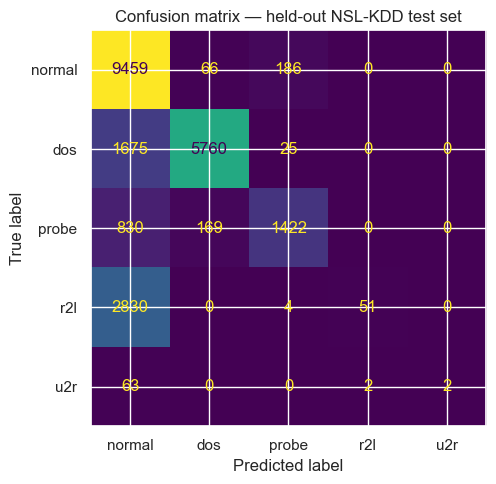

In [9]:
cm = confusion_matrix(y_test, y_pred, labels=labels_order)
fig, ax = plt.subplots(figsize=(6, 5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels_order)
disp.plot(ax=ax, cmap="viridis", colorbar=False, values_format="d")
ax.set_title("Confusion matrix — held-out NSL-KDD test set")
plt.tight_layout()
plt.show()


**Reading the confusion matrix:** NSL-KDD's test set deliberately includes
attack *sub-types* absent from training, so some degradation versus a
random-split evaluation is expected and is itself informative — it's testing
generalization to genuinely novel attack variants, not just memorization of
the training distribution. R2L/U2R classes are typically the hardest here
because they're a small fraction of the data and behaviorally closer to
normal traffic than DoS/probe are.

## 7. Feature importance

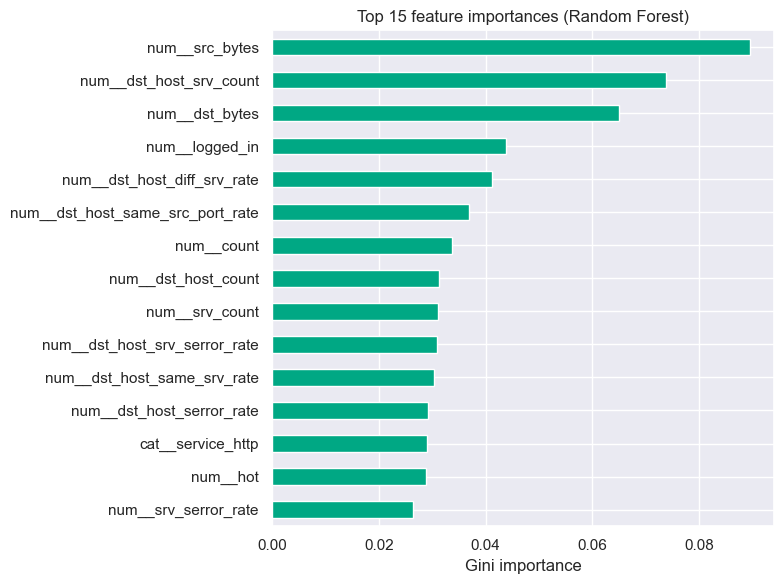

num__src_bytes                      0.089551
num__dst_host_srv_count             0.073820
num__dst_bytes                      0.064997
num__logged_in                      0.043899
num__dst_host_diff_srv_rate         0.041163
num__dst_host_same_src_port_rate    0.036898
num__count                          0.033761
num__dst_host_count                 0.031321
num__srv_count                      0.031156
num__dst_host_srv_serror_rate       0.030852
num__dst_host_same_srv_rate         0.030294
num__dst_host_serror_rate           0.029182
cat__service_http                   0.029036
num__hot                            0.028938
num__srv_serror_rate                0.026489
dtype: float64

In [10]:
model = clf.named_steps["model"]
feature_names = clf.named_steps["preprocess"].get_feature_names_out()
importances = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)

top_n = 15
fig, ax = plt.subplots(figsize=(8, 6))
importances.head(top_n).iloc[::-1].plot(kind="barh", ax=ax, color="#00a884")
ax.set_title(f"Top {top_n} feature importances (Random Forest)")
ax.set_xlabel("Gini importance")
plt.tight_layout()
plt.show()

importances.head(top_n)


Features like `same_srv_rate`, `dst_host_srv_count`, `src_bytes`, and the
various `serror_rate`/`rerror_rate` columns tend to dominate — connection
volume and error-rate statistics are exactly what you'd expect to be
discriminative for flooding-style DoS/DDoS traffic, which lines up with
domain intuition and is a good interview talking point (the model isn't
relying on anything spurious).

## 8. Why the live system doesn't do this

This is the connective tissue back to
[`02_TECHNICAL_ARCHITECTURE.md`](../02_TECHNICAL_ARCHITECTURE.md) section
5b, so this notebook and the live CyberPulse app read as one coherent
project rather than two unrelated things bolted together.

**This notebook's setup:** full per-connection flow features (byte counts,
timing, error rates, service/flag/protocol) extracted from raw traffic —
the kind of data a tool like CICFlowMeter produces from packet captures.
With that kind of access, a classic supervised model does a solid job
distinguishing DoS/probe/R2L/U2R from normal traffic, as shown above.

**The live system's actual constraint:** CyberPulse has no packet-level or
flow-level access to any real network. It only ever sees what
AbuseIPDB's community already aggregated and reported — an IP address, a
handful of report-count/reporter-count statistics, and a set of
crowd-assigned category tags. There is no "connection duration" or
"src_bytes" to work with, because there's no connection being observed live
in the first place.

That's *why* the live system's risk scorer (`app/ml/`) is a much simpler
model trained on weak/proxy-labeled AbuseIPDB metadata (report counts,
reporter diversity, recency, category tags, ASN type) rather than anything
resembling this notebook's flow features — it's not a simplification for
convenience, it's the actual shape of the data that's actually available in
a $0, no-packet-capture, third-party-API-only architecture. This notebook
exists to show what the "if we had packet-level access" version of the
problem looks like, and to demonstrate the same classic-ML toolkit
(preprocessing, train/test discipline, evaluation, feature importance)
applied to a harder, richer feature set — not to pretend the live system
has data it doesn't.